In [5]:
import torch
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Make sure Dataloader.py is in the same directory
from TrainONNew.Dataloader import MotionDataset


Initialized MotionDataset with 7071 samples. Training mode: True
OFxuiqI5G44_00402
✅ Loaded tensor with full sequence length: 155 frames.
⚙️  Generating augmented versions...
📹 Creating animation with all 155 frames... This may take a moment.
🎉 Successfully saved visualization to: augmentation_visualization.mp4


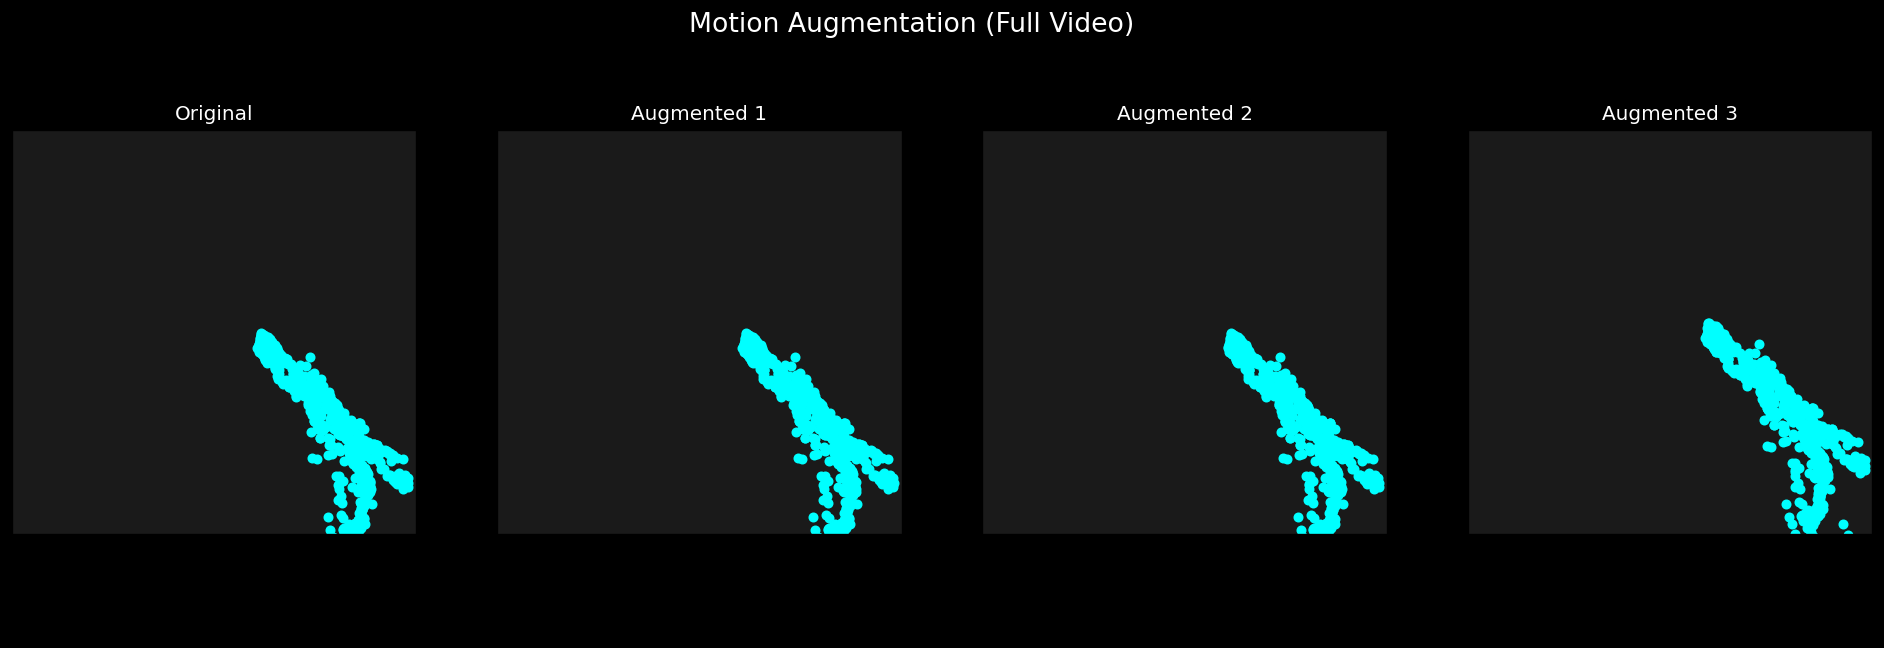

In [17]:
# --- Configuration ---
PT_FOLDER = "videosTensors1000"
OUTPUT_VIDEO_FILE = "augmentation_visualization.mp4"
MAX_POINTS = 1000


def main():
    TRAIN_DF_PATH = "/Users/mrinalraj/Downloads/WebDownload/Driving48/df_exsists.csv"
    train_df = pd.read_csv(TRAIN_DF_PATH)
    
    dataset = MotionDataset(
        df=train_df, pt_folder=PT_FOLDER, training=True, max_points=MAX_POINTS, p_aug=1.0
    )

    # Get one processed sample
    original_tensor, _, __ = dataset[100]
    print(__)
    # --- GET THE ACTUAL VIDEO LENGTH ---
    # Get the number of frames from the loaded tensor's shape (dim 0)
    # This ensures the animation is for the full video clip.
    seq_length = original_tensor.shape[0]
    
    print(f"✅ Loaded tensor with full sequence length: {seq_length} frames.")
    
    print("⚙️  Generating augmented versions...")
    augmented_tensors = [dataset._augment_motion(original_tensor.clone()) for _ in range(NUM_AUGMENTATIONS)]
    
    all_tensors = [original_tensor] + augmented_tensors
    titles = ["Original"] + [f"Augmented {i+1}" for i in range(NUM_AUGMENTATIONS)]
    
    # Set up the plot for a cleaner "video" style
    num_plots = len(all_tensors)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5.5), dpi=120)
    fig.suptitle("Motion Augmentation (Full Video)", fontsize=16, color='white')
    fig.patch.set_facecolor('black')

    scatters = []
    for i, ax in enumerate(axes):
        ax.set_title(titles[i], color='white')
        ax.set_facecolor('#1a1a1a')
        ax.set_xlim(-0.2, 1.2)
        ax.set_ylim(-0.2, 1.2)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal', 'box')
        scatters.append(ax.scatter([], [], s=25, c='#00FFFF'))

    frame_text = fig.text(0.5, 0.04, '', ha='center', fontsize=12, color='white')

    def update(frame_idx):
        artists = []
        for i, tensor in enumerate(all_tensors):
            coords = tensor[frame_idx, :, :2]
            active_mask = coords.sum(dim=-1) != 0
            active_coords = coords[active_mask].numpy()
            scatters[i].set_offsets(active_coords)
            artists.append(scatters[i])
        
        frame_text.set_text(f'Frame: {frame_idx + 1} / {seq_length}')
        artists.append(frame_text)
        return artists

    print(f"📹 Creating animation with all {seq_length} frames... This may take a moment.")
    
    # --- USE THE DYNAMIC seq_length VARIABLE ---
    ani = FuncAnimation(fig, update, frames=seq_length, blit=True, interval=50)
    
    try:
        ani.save(OUTPUT_VIDEO_FILE, writer='ffmpeg', fps=20, savefig_kwargs={'facecolor': 'black'})
        print(f"🎉 Successfully saved visualization to: {OUTPUT_VIDEO_FILE}")
    except Exception as e:
        print(f"❌ Error saving animation: {e}")
        print("Please ensure 'ffmpeg' is installed and accessible in your system's PATH.")

if __name__ == '__main__':
    main()